In [2]:
# powerRotor
# In the Powerlift folder, there are subfolders named after 4 yaw angles i.e. 270,276,282,285. Each subfolder in turn contains multiple subfolders named after the timestep say 19022.002, etc. 
# Each such subfolders has a file named "powerRotor". Thus, there are multiple files named "powerRotor" in the Powerlift folder structure.Can you go through all the subfolders in Powerlift, read each "powerRotor" file, extract all the values corresponding to the two columns: Time(s) and rotor power (W) in all the files.  Then concatenate them and create a csv file with three columns: the yaw angle (from the name of the subfolder to which the powerRotor file belongs), the  Time(s) and the rotor power (W).

In [2]:
import os
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path(r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift")

# Yaw angle folders
yaw_folders = ['270', '276', '282', '285']

# List to store all dataframes
all_data = []

# Iterate through each yaw angle folder
for yaw in yaw_folders:
    yaw_path = base_dir / yaw
    if yaw_path.exists():
        # Iterate through each timestep subfolder
        for timestep_folder in yaw_path.iterdir():
            if timestep_folder.is_dir():
                power_file = timestep_folder / 'powerRotor'
                if power_file.exists():
                    # Read the powerRotor file (space-separated, skip header)
                    df = pd.read_csv(power_file, sep=r'\s+', 
                                     names=['Turbine', 'Time(s)', 'dt(s)', 'rotor power (W)'],
                                     skiprows=1)
                    # Add yaw angle column
                    df['yaw_angle'] = int(yaw)
                    # Keep only the columns we need
                    df = df[['yaw_angle', 'Time(s)', 'rotor power (W)']]
                    all_data.append(df)
                    print(f"Loaded: {power_file}")

# Concatenate all dataframes
combined_df = pd.concat(all_data, ignore_index=True)

# Sort by yaw angle and time
combined_df = combined_df.sort_values(['yaw_angle', 'Time(s)']).reset_index(drop=True)

print(f"\nTotal records: {len(combined_df)}")
print(combined_df.head(10))

ValueError: No objects to concatenate

# Save to CSV file
output_file = base_dir / 'powerRotor_combined.csv'
combined_df.to_csv(output_file, index=False)
print(f"CSV file saved to: {output_file}")

In [3]:
# Load the CSV file
csv_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\powerRotor_combined.csv"
df = pd.read_csv(csv_path)

print(f"Shape: {df.shape}")
print(df.head())

Shape: (2829, 3)
   yaw_angle       Time(s)  rotor power (W)
0        270  19022.802301     3.593848e+06
1        270  19118.333632     1.507120e+06
2        270  19202.966095     1.271730e+06
3        270  19290.167171     1.162377e+06
4        270  19379.515534     1.358793e+06


In [4]:
df.shape

(2829, 3)

# Machine Learning Model for Rotor Power Prediction with Uncertainty Quantification

## Strategy:
1. **Normalize time** to relative time (0 to 1) within each yaw trajectory so we can predict dynamics without knowing absolute time
2. Train a **Gaussian Process Regression** model with uncertainty quantification
3. Save the model for later inference
4. Create an **agent class** that can be called to predict power dynamics for any new yaw angle

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
csv_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\powerRotor_combined.csv"
df = pd.read_csv(csv_path)

# Convert power from W to MW
df['rotor_power_MW'] = df['rotor power (W)'] / 1e6

# Create normalized time (0 to 1) within each yaw angle group
# This allows prediction without knowing absolute time
def normalize_time_per_group(group):
    t_min = group['Time(s)'].min()
    t_max = group['Time(s)'].max()
    if t_max > t_min:
        group['normalized_time'] = (group['Time(s)'] - t_min) / (t_max - t_min)
    else:
        group['normalized_time'] = 0.0
    return group

df = df.groupby('yaw_angle', group_keys=False).apply(normalize_time_per_group)

print("Data with normalized time:")
print(df.head(20))
print(f"\nUnique yaw angles: {df['yaw_angle'].unique()}")
print(f"Shape: {df.shape}")

Data with normalized time:
    yaw_angle       Time(s)  rotor power (W)  rotor_power_MW  normalized_time
0         270  19022.802301     3.593848e+06        3.593848         0.000000
1         270  19118.333632     1.507120e+06        1.507120         0.062439
2         270  19202.966095     1.271730e+06        1.271730         0.117754
3         270  19290.167171     1.162377e+06        1.162377         0.174748
4         270  19379.515534     1.358793e+06        1.358793         0.233146
5         270  19467.511590     1.489887e+06        1.489887         0.290660
6         270  19553.925899     1.084942e+06        1.084942         0.347140
7         270  19640.377862     1.238586e+06        1.238586         0.403644
8         270  19727.673937     9.643879e+05        0.964388         0.460700
9         270  19816.729760     1.617096e+06        1.617096         0.518907
10        270  19904.559497     1.368471e+06        1.368471         0.576312
11        270  19991.870307     1.144

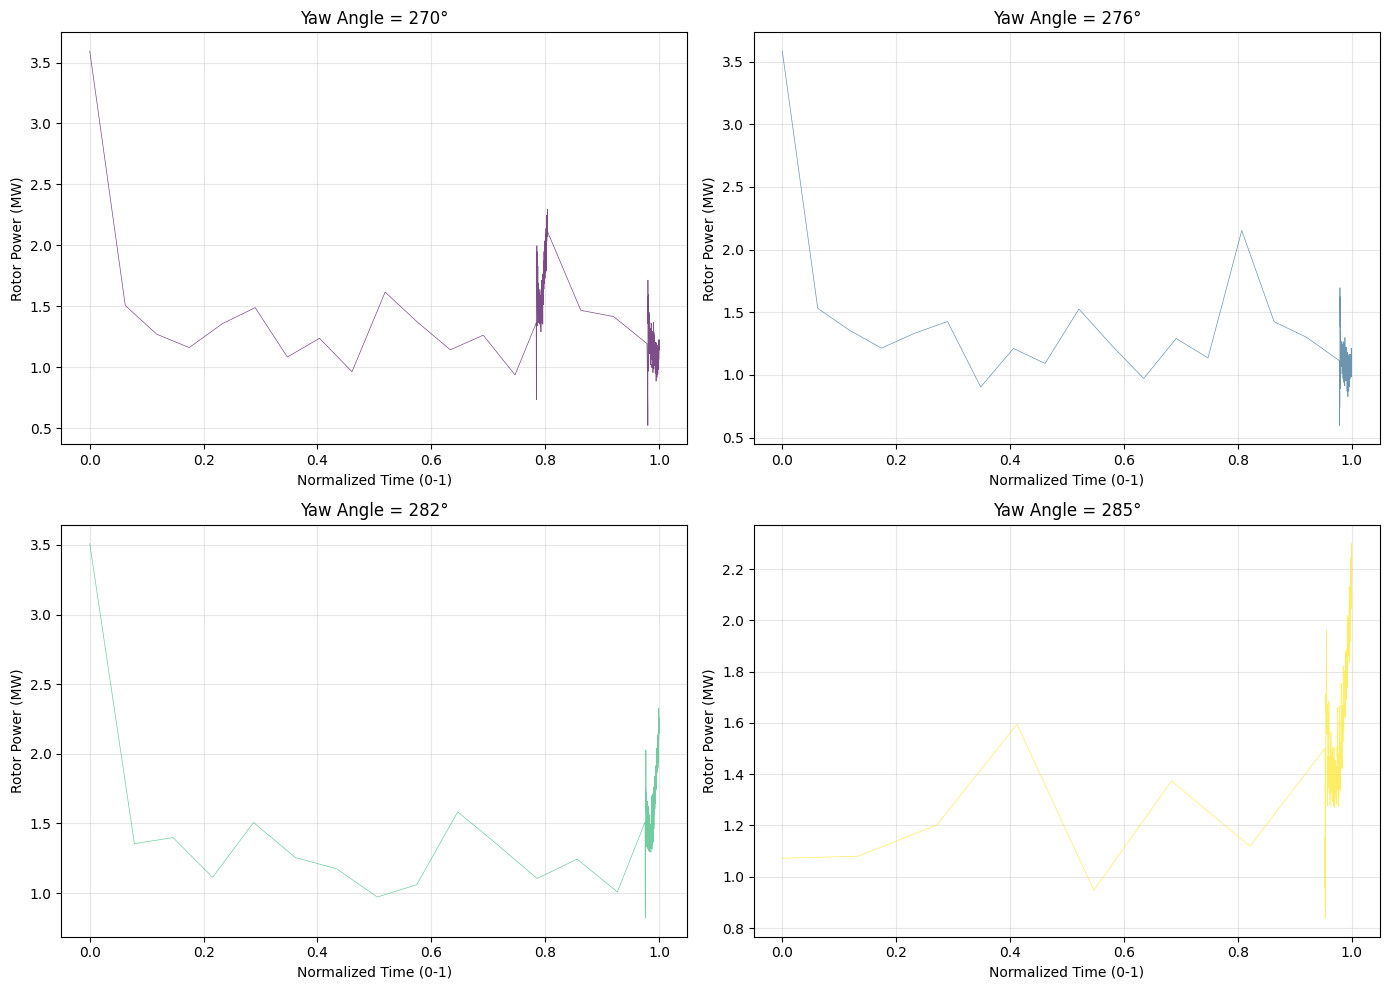

Power dynamics visualization saved to 'power_dynamics_by_yaw.png'


In [20]:
# Visualize the data - power dynamics for each yaw angle
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

yaw_angles = sorted(df['yaw_angle'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))

for idx, yaw in enumerate(yaw_angles):
    yaw_data = df[df['yaw_angle'] == yaw]
    axes[idx].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                   color=colors[idx], alpha=0.7, linewidth=0.5)
    axes[idx].set_xlabel('Normalized Time (0-1)')
    axes[idx].set_ylabel('Rotor Power (MW)')
    axes[idx].set_title(f'Yaw Angle = {yaw}°')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_dynamics_by_yaw.png', dpi=150)
plt.show()
print("Power dynamics visualization saved to 'power_dynamics_by_yaw.png'")

## Model Training with Uncertainty Quantification

We use **Gaussian Process Regression (GPR)** because:
1. It provides built-in **uncertainty quantification** (mean + variance)
2. It works well with small to medium datasets
3. It can capture non-linear relationships

For large datasets, we subsample to make GPR computationally feasible.

## Outlier Detection and Removal

Before training the model, we need to detect and remove outliers from the dataset. We'll use multiple methods:
1. **IQR (Interquartile Range) Method**: Detects outliers based on statistical quartiles
2. **Z-Score Method**: Identifies data points that are too many standard deviations away from the mean
3. **Isolation Forest**: ML-based anomaly detection

This ensures the model is trained on clean, representative data.

Original dataset size: 2829 rows
Yaw angles: [np.int64(270), np.int64(276), np.int64(282), np.int64(285)]

Power statistics before outlier removal:
count    2829.000000
mean        1.452096
std         0.331860
min         0.523434
25%         1.164838
50%         1.424575
75%         1.665911
max         3.593848
Name: rotor_power_MW, dtype: float64

Applying IQR-based outlier detection per yaw angle...

OUTLIER REMOVAL SUMMARY
Original dataset size:          2,829 rows
Cleaned dataset size:           2,802 rows
Outliers removed:                  27 rows (0.95%)

Outliers removed per yaw angle:
  Yaw 270°:      1 outliers removed (out of  1,222 rows)
  Yaw 276°:     24 outliers removed (out of    382 rows)
  Yaw 282°:      2 outliers removed (out of    616 rows)
  Yaw 285°:      0 outliers removed (out of    609 rows)

Power statistics after outlier removal:
count    2802.000000
mean        1.450799
std         0.324190
min         0.523434
25%         1.164520
50%         1.423097
75

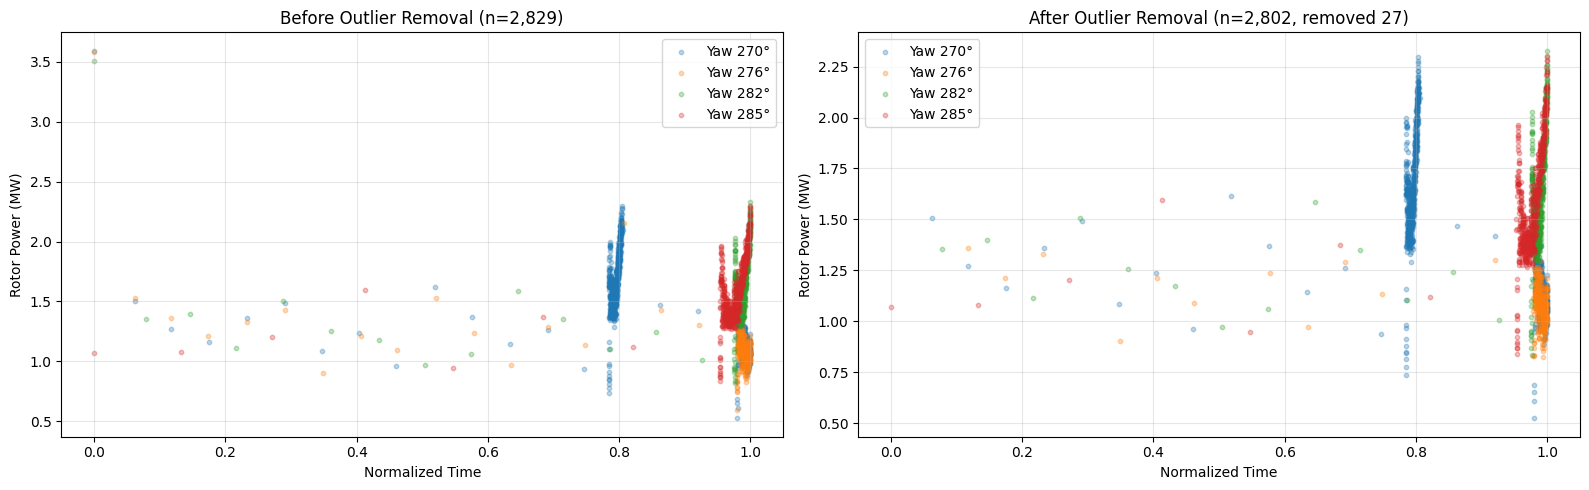


Visualization saved to 'outlier_removal_comparison.png'

✓ Dataset updated with outlier-free data (2,802 rows)
✓ Ready for train/test split and model training


In [21]:
from sklearn.ensemble import IsolationForest
from scipy import stats

# Store original dataset size
original_size = len(df)
print(f"Original dataset size: {original_size} rows")
print(f"Yaw angles: {sorted(df['yaw_angle'].unique())}")
print(f"\nPower statistics before outlier removal:")
print(df['rotor_power_MW'].describe())

# Method 1: IQR Method (Interquartile Range) - per yaw angle group
def remove_outliers_iqr(group, column='rotor_power_MW', multiplier=1.5):
    """Remove outliers using IQR method within each group"""
    Q1 = group[column].quantile(0.25)
    Q3 = group[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return group[(group[column] >= lower_bound) & (group[column] <= upper_bound)]

# Method 2: Z-Score Method - per yaw angle group
def remove_outliers_zscore(group, column='rotor_power_MW', threshold=3):
    """Remove outliers using Z-score method within each group"""
    z_scores = np.abs(stats.zscore(group[column]))
    return group[z_scores < threshold]

# Method 3: Isolation Forest - Applied globally
def remove_outliers_isolation_forest(df, column='rotor_power_MW', contamination=0.05):
    """Remove outliers using Isolation Forest"""
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    # Reshape for sklearn
    X_iso = df[[column]].values
    predictions = iso_forest.fit_predict(X_iso)
    # Keep only inliers (prediction = 1)
    return df[predictions == 1]

# Apply outlier removal - using IQR method per yaw angle group
print("\n" + "="*60)
print("Applying IQR-based outlier detection per yaw angle...")
print("="*60)

df_cleaned = df.groupby('yaw_angle', group_keys=False).apply(
    lambda group: remove_outliers_iqr(group, column='rotor_power_MW', multiplier=1.5)
).reset_index(drop=True)

removed_rows = original_size - len(df_cleaned)
removal_percentage = (removed_rows / original_size) * 100

print(f"\n{'='*60}")
print(f"OUTLIER REMOVAL SUMMARY")
print(f"{'='*60}")
print(f"Original dataset size:     {original_size:>10,} rows")
print(f"Cleaned dataset size:      {len(df_cleaned):>10,} rows")
print(f"Outliers removed:          {removed_rows:>10,} rows ({removal_percentage:.2f}%)")
print(f"{'='*60}")

# Show statistics per yaw angle
print(f"\nOutliers removed per yaw angle:")
for yaw in sorted(df['yaw_angle'].unique()):
    original_count = len(df[df['yaw_angle'] == yaw])
    cleaned_count = len(df_cleaned[df_cleaned['yaw_angle'] == yaw])
    removed = original_count - cleaned_count
    print(f"  Yaw {yaw}°: {removed:>6,} outliers removed (out of {original_count:>6,} rows)")

print(f"\nPower statistics after outlier removal:")
print(df_cleaned['rotor_power_MW'].describe())

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before outlier removal
for yaw in sorted(df['yaw_angle'].unique()):
    yaw_data = df[df['yaw_angle'] == yaw]
    axes[0].scatter(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                   alpha=0.3, s=10, label=f'Yaw {yaw}°')
axes[0].set_xlabel('Normalized Time')
axes[0].set_ylabel('Rotor Power (MW)')
axes[0].set_title(f'Before Outlier Removal (n={original_size:,})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After outlier removal
for yaw in sorted(df_cleaned['yaw_angle'].unique()):
    yaw_data = df_cleaned[df_cleaned['yaw_angle'] == yaw]
    axes[1].scatter(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                   alpha=0.3, s=10, label=f'Yaw {yaw}°')
axes[1].set_xlabel('Normalized Time')
axes[1].set_ylabel('Rotor Power (MW)')
axes[1].set_title(f'After Outlier Removal (n={len(df_cleaned):,}, removed {removed_rows:,})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_removal_comparison.png', dpi=150)
plt.show()

print(f"\nVisualization saved to 'outlier_removal_comparison.png'")

# Replace df with cleaned version for subsequent training
df = df_cleaned.copy()
print(f"\n✓ Dataset updated with outlier-free data ({len(df):,} rows)")
print(f"✓ Ready for train/test split and model training")

In [8]:
df

,yaw_angle,Time(s),rotor power (W),rotor_power_MW,normalized_time
0,270,19118.333632,1.507120e+06,1.507120,0.062439
1,270,19202.966095,1.271730e+06,1.271730,0.117754
2,270,19290.167171,1.162377e+06,1.162377,0.174748
3,270,19379.515534,1.358793e+06,1.358793,0.233146
4,270,19467.511590,1.489887e+06,1.489887,0.290660
...,...,...,...,...,...
2797,285,20252.702301,2.222077e+06,2.222077,0.999688
2798,285,20252.752301,2.144829e+06,2.144829,0.999766
2799,285,20252.802301,2.160072e+06,2.160072,0.999844
2800,285,20252.852301,2.206789e+06,2.206789,0.999922


In [60]:
from scipy.signal import savgol_filter
from scipy.ndimage import binary_dilation
import numpy as np

def smooth_rapid_regions(group, rate_threshold=3.0, window_length=11, polyorder=3, extend_region=5):
    """
    Automatically detect and smooth ONLY regions with rapid changes.
    Preserves the rest of the signal untouched.
    """
    group = group.sort_values('normalized_time').copy()
    
    # Calculate rate of change (derivative)
    time_diff = group['normalized_time'].diff().fillna(0)
    power_diff = group['rotor_power_MW'].diff().fillna(0)
    rate_of_change = np.where(time_diff > 0, np.abs(power_diff / time_diff), 0)
    
    # Mark ONLY problematic regions (high rate of change)
    problematic = rate_of_change > rate_threshold
    
    # Extend the mask slightly around spikes
    if extend_region > 0:
        problematic = binary_dilation(problematic, iterations=extend_region)
    
    # Copy original data
    smoothed_power = group['rotor_power_MW'].values.copy()
    
    if np.any(problematic) and len(smoothed_power) >= window_length:
        # Find contiguous problematic regions
        regions = []
        in_region = False
        start = 0
        
        for i, is_prob in enumerate(problematic):
            if is_prob and not in_region:
                start = i
                in_region = True
            elif not is_prob and in_region:
                regions.append((start, i))
                in_region = False
        
        if in_region:
            regions.append((start, len(problematic)))
        
        # Smooth ONLY these regions
        for start, end in regions:
            region_length = end - start
            if region_length >= window_length:
                wl = min(window_length, region_length if region_length % 2 == 1 else region_length - 1)
                smoothed_power[start:end] = savgol_filter(
                    smoothed_power[start:end], wl, polyorder
                )
            elif region_length >= 3:
                # Simple moving average for tiny regions
                smoothed_power[start:end] = np.convolve(
                    smoothed_power[start:end], np.ones(3)/3, mode='same'
                )
    
    group['rotor_power_MW'] = smoothed_power
    group['smoothed_region'] = problematic  # Track which points were smoothed
    
    return group

# Apply to your data
print("Applying localized smoothing to rapid fluctuation regions only...")
print("="*70)

df_smoothed = df.groupby('yaw_angle', group_keys=False).apply(
    lambda group: smooth_rapid_regions(
        group, 
        rate_threshold=1000.0,    # ← Higher = only smooth extreme spikes
        window_length=10,      # ← Smoothing window size
        polyorder=3,
        extend_region=1        # ← Smooth a few points around the spike
    )
).reset_index(drop=True)

smoothed_points = df_smoothed['smoothed_region'].sum()
total_points = len(df_smoothed)
print(f"✓ Smoothed {smoothed_points:,} points ({smoothed_points/total_points*100:.2f}%)")
print(f"✓ Preserved {total_points - smoothed_points:,} original points")
print("="*70)

Applying localized smoothing to rapid fluctuation regions only...
✓ Smoothed 1,823 points (65.06%)
✓ Preserved 979 original points


In [61]:
# Show exactly which regions were smoothed
def visualize_smoothed_regions(df):
        
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    yaw_angles = sorted(df['yaw_angle'].unique())

    for idx, yaw in enumerate(yaw_angles):
        yaw_data = df[df['yaw_angle'] == yaw].sort_values('normalized_time')
        
        # Plot the final smoothed signal
        axes[idx].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    linewidth=1.5, color='blue', alpha=0.8, label='Final Signal')
        
        # Highlight the smoothed regions in RED
        smoothed_mask = yaw_data['smoothed_region'].values
        if smoothed_mask.any():
            axes[idx].scatter(
                yaw_data.loc[smoothed_mask, 'normalized_time'],
                yaw_data.loc[smoothed_mask, 'rotor_power_MW'],
                color='red', s=30, alpha=0.6, 
                label=f'Smoothed regions ({smoothed_mask.sum()} pts)', 
                zorder=5
            )
        
        axes[idx].set_xlabel('Normalized Time', fontsize=11)
        axes[idx].set_ylabel('Rotor Power (MW)', fontsize=11)
        axes[idx].set_title(f'Yaw {yaw}° - Localized Smoothing', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('localized_smoothing_regions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Red points show exactly which regions were smoothed")
    print("✓ Blue regions remain untouched from original data")

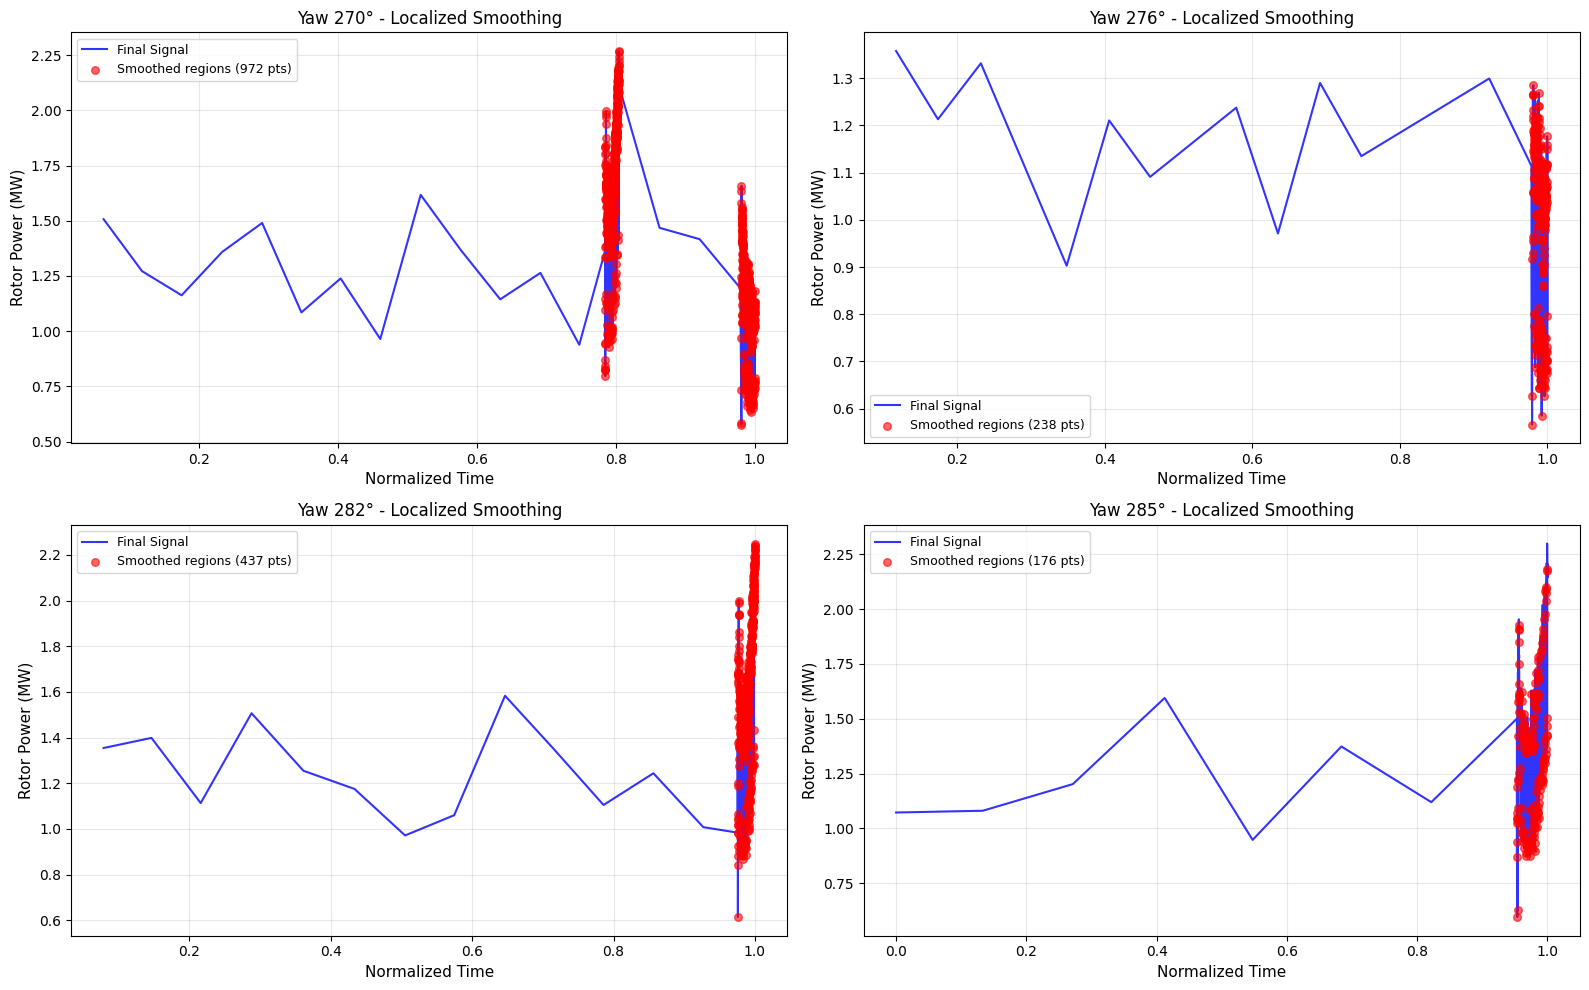

✓ Red points show exactly which regions were smoothed
✓ Blue regions remain untouched from original data


In [62]:
visualize_smoothed_regions(df_smoothed)

In [63]:
# Before outlier removal
def fig_compare(df, df_cleaned):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for yaw in sorted(df['yaw_angle'].unique()):
        yaw_data = df[df['yaw_angle'] == yaw]
        axes[0].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    alpha=0.3,  label=f'Yaw {yaw}°')
    axes[0].set_xlabel('Normalized Time')
    axes[0].set_ylabel('Rotor Power (MW)')
    axes[0].set_title(f'Before Outlier Removal (n={original_size:,})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # After outlier removal
    for yaw in sorted(df_cleaned['yaw_angle'].unique()):
        yaw_data = df_cleaned[df_cleaned['yaw_angle'] == yaw]
        axes[1].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    alpha=0.3,  label=f'Yaw {yaw}°')
    axes[1].set_xlabel('Normalized Time')
    axes[1].set_ylabel('Rotor Power (MW)')
    axes[1].set_title(f'After smoothing (n={len(df_cleaned):,}, removed {removed_rows:,})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

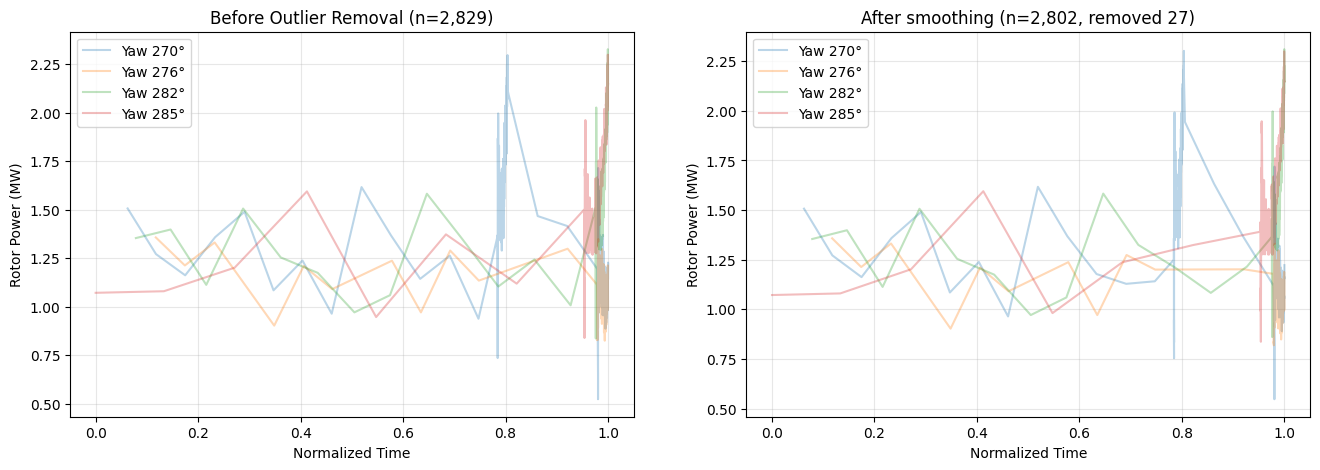

In [56]:
fig_compare(df, df_smoothed)

In [119]:
from scipy.ndimage import binary_dilation
import numpy as np

def detect_and_handle_spikes(group, rate_threshold=1000.0, 
                              method='average',  # 'average' or 'remove'
                              n_surrounding_points=5,
                              extend_region=0):
    """
    Detect problematic points based on rate of change and handle them.
    
    Args:
        rate_threshold: Threshold for rate of change to identify spikes
        method: 'average' or 'remove'
            - 'average': Replace spike with average of N surrounding points
            - 'remove': Remove all spike points from dataset
        n_surrounding_points: Number of surrounding points to average (for method='average')
        extend_region: Number of points to extend around detected spikes
    
    Returns:
        Modified group with spikes handled according to method
    """
    group = group.sort_values('normalized_time').copy()
    
    # Calculate rate of change (derivative)
    time_diff = group['normalized_time'].diff().fillna(0)
    power_diff = group['rotor_power_MW'].diff().fillna(0)
    rate_of_change = np.where(time_diff > 0, np.abs(power_diff / time_diff), 0)
    
    # Mark problematic points (high rate of change)
    problematic = rate_of_change > rate_threshold
    
    # Optionally extend the mask around spikes
    if extend_region > 0:
        problematic = binary_dilation(problematic, iterations=extend_region)
    
    # Track which points are problematic
    group['is_spike'] = problematic
    
    n_spikes = problematic.sum()
    
    if n_spikes == 0:
        print(f"  No spikes detected (threshold={rate_threshold})")
        return group
    
    if method == 'remove':
        # OPTION 1: Remove all spike points
        group_cleaned = group[~problematic].copy()
        print(f"  Removed {n_spikes} spike points")
        return group_cleaned
    
    elif method == 'average':
        # OPTION 2: Replace spikes with average of surrounding points
        smoothed_power = group['rotor_power_MW'].values.copy()
        spike_indices = np.where(problematic)[0]
        
        for spike_idx in spike_indices:
            # Find surrounding valid (non-spike) points
            start_idx = max(0, spike_idx - n_surrounding_points)
            end_idx = min(len(group), spike_idx + n_surrounding_points + 1)
            
            # Get surrounding points that are NOT spikes
            surrounding_mask = np.zeros(len(group), dtype=bool)
            surrounding_mask[start_idx:end_idx] = True
            valid_surrounding = surrounding_mask & ~problematic
            
            if np.any(valid_surrounding):
                # Replace spike with average of valid surrounding points
                avg_power = np.mean(smoothed_power[valid_surrounding])
                smoothed_power[spike_idx] = avg_power
            else:
                # Fallback: if no valid surrounding points, use global mean
                print(f"    ⚠️ Warning: No valid points around index {spike_idx}, using overall mean")
                smoothed_power[spike_idx] = np.mean(smoothed_power[~problematic])
        
        group['rotor_power_MW'] = smoothed_power
        print(f"  Averaged {n_spikes} spike points using {n_surrounding_points} surrounding points")
        return group
    
    else:
        raise ValueError(f"Invalid method: {method}. Use 'average' or 'remove'")


# =============================================================================
# USAGE: Choose your method
# =============================================================================

print("="*70)
print("SPIKE DETECTION AND HANDLING")
print("="*70)

# -------------------------------
# OPTION 1: Replace with Average
# -------------------------------
print("\n[METHOD 1] Replacing spikes with average of surrounding points...")
df_averaged = df.groupby('yaw_angle', group_keys=False).apply(
    lambda group: detect_and_handle_spikes(
        group, 
        rate_threshold=8.0,           # ← Adjust to detect spikes
        method='average',                # ← Replace with average
        n_surrounding_points=1000,         # ← Use ±50 points for averaging
        extend_region=0                  # ← Don't extend spike detection
    )
).reset_index(drop=True)

spike_points = df_averaged['is_spike'].sum()
print(f"\n✓ Processed {spike_points:,} spike points")
print(f"✓ Dataset size: {len(df_averaged):,} rows (unchanged)")
print("="*70)

# -------------------------------
# OPTION 2: Remove Spikes
# -------------------------------
print("\n[METHOD 2] Removing all spike points from dataset...")
df_removed = df.groupby('yaw_angle', group_keys=False).apply(
    lambda group: detect_and_handle_spikes(
        group, 
        rate_threshold=8.0,           # ← Adjust to detect spikes
        method='remove',                 # ← Remove spikes completely
        extend_region=0                  # ← Don't extend spike detection
    )
).reset_index(drop=True)

original_size = len(df)
removed_count = original_size - len(df_removed)
print(f"\n✓ Removed {removed_count:,} spike points")
print(f"✓ Dataset size: {len(df_removed):,} rows (reduced by {removed_count/original_size*100:.2f}%)")
print("="*70)

# -------------------------------
# Choose which method to use
# -------------------------------
print("\n" + "="*70)
print("Which method do you want to use?")
print("  1. df_averaged  → Spikes replaced with average")
print("  2. df_removed   → Spikes removed from dataset")
print("="*70)

SPIKE DETECTION AND HANDLING

[METHOD 1] Replacing spikes with average of surrounding points...
  Averaged 1202 spike points using 1000 surrounding points
  Averaged 341 spike points using 1000 surrounding points
  Averaged 595 spike points using 1000 surrounding points
  Averaged 599 spike points using 1000 surrounding points

✓ Processed 2,737 spike points
✓ Dataset size: 2,802 rows (unchanged)

[METHOD 2] Removing all spike points from dataset...
  Removed 1202 spike points
  Removed 341 spike points
  Removed 595 spike points
  Removed 599 spike points

✓ Removed 2,737 spike points
✓ Dataset size: 65 rows (reduced by 97.68%)

Which method do you want to use?
  1. df_averaged  → Spikes replaced with average
  2. df_removed   → Spikes removed from dataset


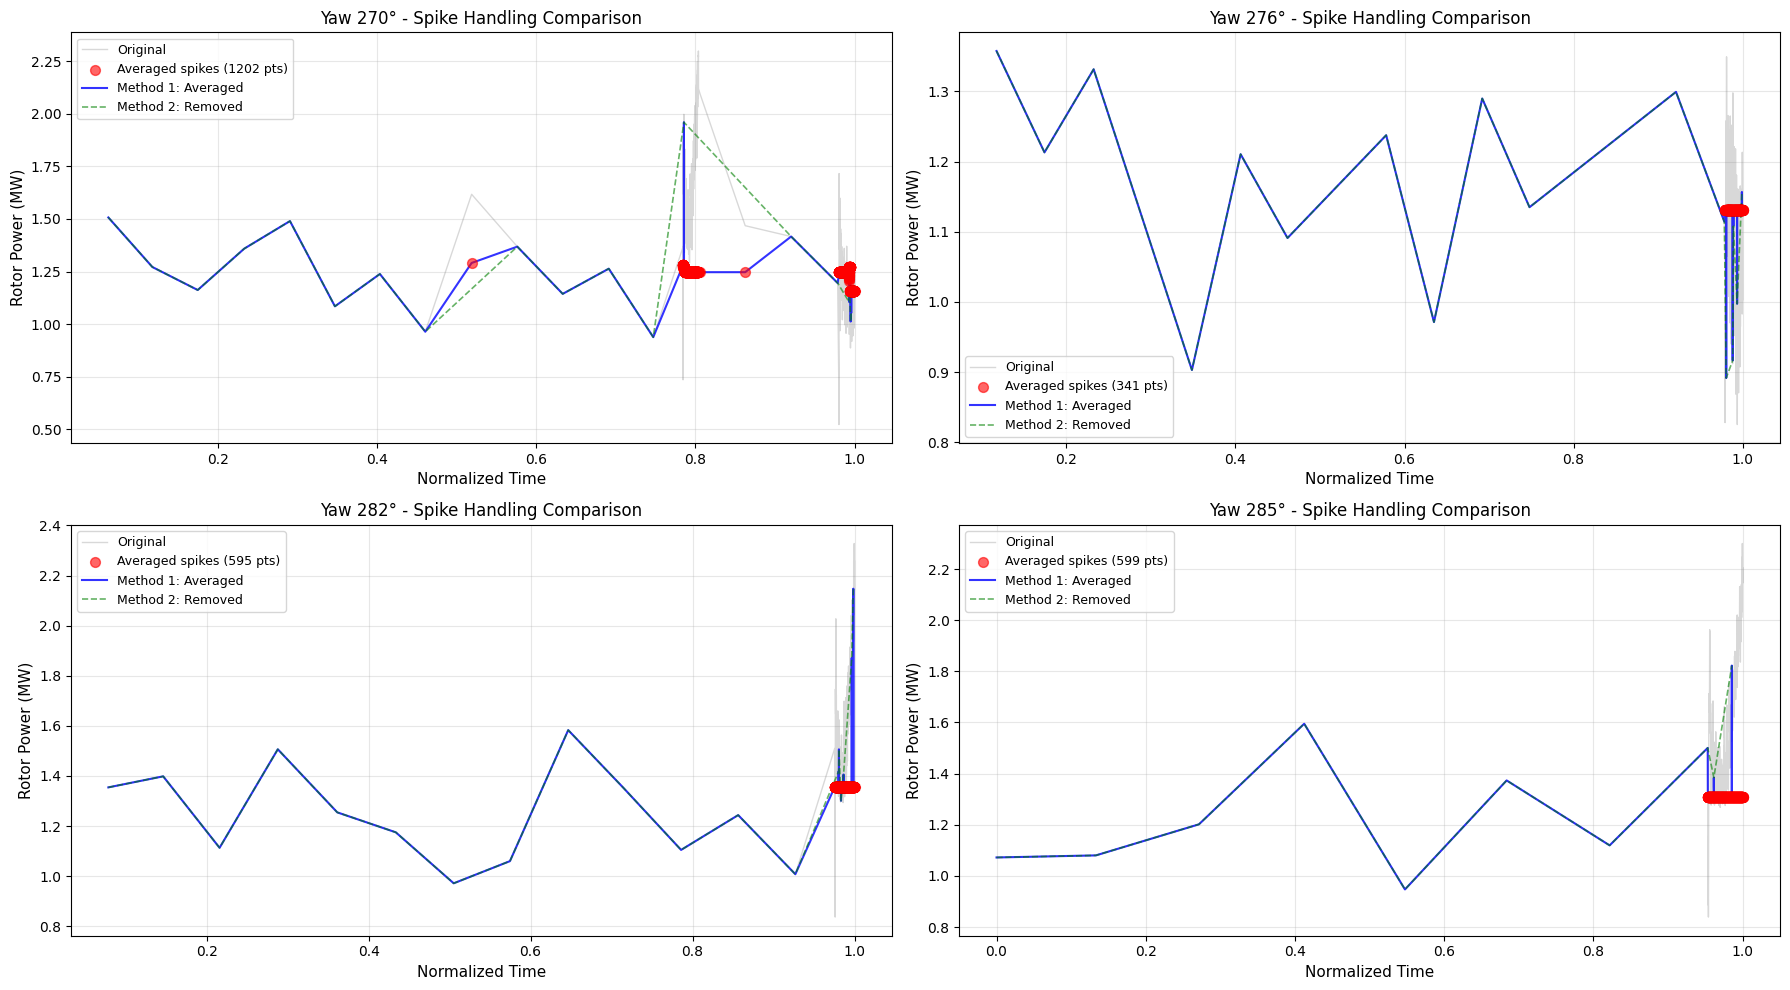

✓ Gray = Original signal
✓ Blue = Spikes replaced with average
✓ Green (dashed) = Spikes removed (gaps in data)
✓ Red circles = Detected spike locations


In [120]:
def visualize_spike_handling_comparison(df_original, df_averaged, df_removed):
    """
    Compare original, averaged, and removed spike handling methods.
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    yaw_angles = sorted(df_original['yaw_angle'].unique())

    for idx, yaw in enumerate(yaw_angles):
        ax = axes[idx]
        
        # Original data
        yaw_orig = df_original[df_original['yaw_angle'] == yaw].sort_values('normalized_time')
        
        # Averaged data
        yaw_avg = df_averaged[df_averaged['yaw_angle'] == yaw].sort_values('normalized_time')
        
        # Removed data
        yaw_rem = df_removed[df_removed['yaw_angle'] == yaw].sort_values('normalized_time')
        
        # Plot original (gray background)
        ax.plot(yaw_orig['normalized_time'], yaw_orig['rotor_power_MW'], 
               color='gray', alpha=0.3, linewidth=1, label='Original')
        
        # Highlight spike points in red
        if 'is_spike' in yaw_avg.columns:
            spike_mask = yaw_avg['is_spike'].values
            if spike_mask.any():
                ax.scatter(yaw_avg.loc[spike_mask, 'normalized_time'],
                          yaw_avg.loc[spike_mask, 'rotor_power_MW'],
                          color='red', s=50, alpha=0.6, 
                          label=f'Averaged spikes ({spike_mask.sum()} pts)', 
                          zorder=10, marker='o')
        
        # Plot averaged signal
        ax.plot(yaw_avg['normalized_time'], yaw_avg['rotor_power_MW'], 
               color='blue', alpha=0.8, linewidth=1.5, label='Method 1: Averaged')
        
        # Plot removed signal (will have gaps where spikes were)
        ax.plot(yaw_rem['normalized_time'], yaw_rem['rotor_power_MW'], 
               color='green', alpha=0.6, linewidth=1.2, label='Method 2: Removed', 
               linestyle='--')
        
        ax.set_xlabel('Normalized Time', fontsize=11)
        ax.set_ylabel('Rotor Power (MW)', fontsize=11)
        ax.set_title(f'Yaw {yaw}° - Spike Handling Comparison', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='best')

    plt.tight_layout()
    plt.savefig('spike_handling_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Gray = Original signal")
    print("✓ Blue = Spikes replaced with average")
    print("✓ Green (dashed) = Spikes removed (gaps in data)")
    print("✓ Red circles = Detected spike locations")

# Use it
visualize_spike_handling_comparison(df, df_averaged, df_removed)

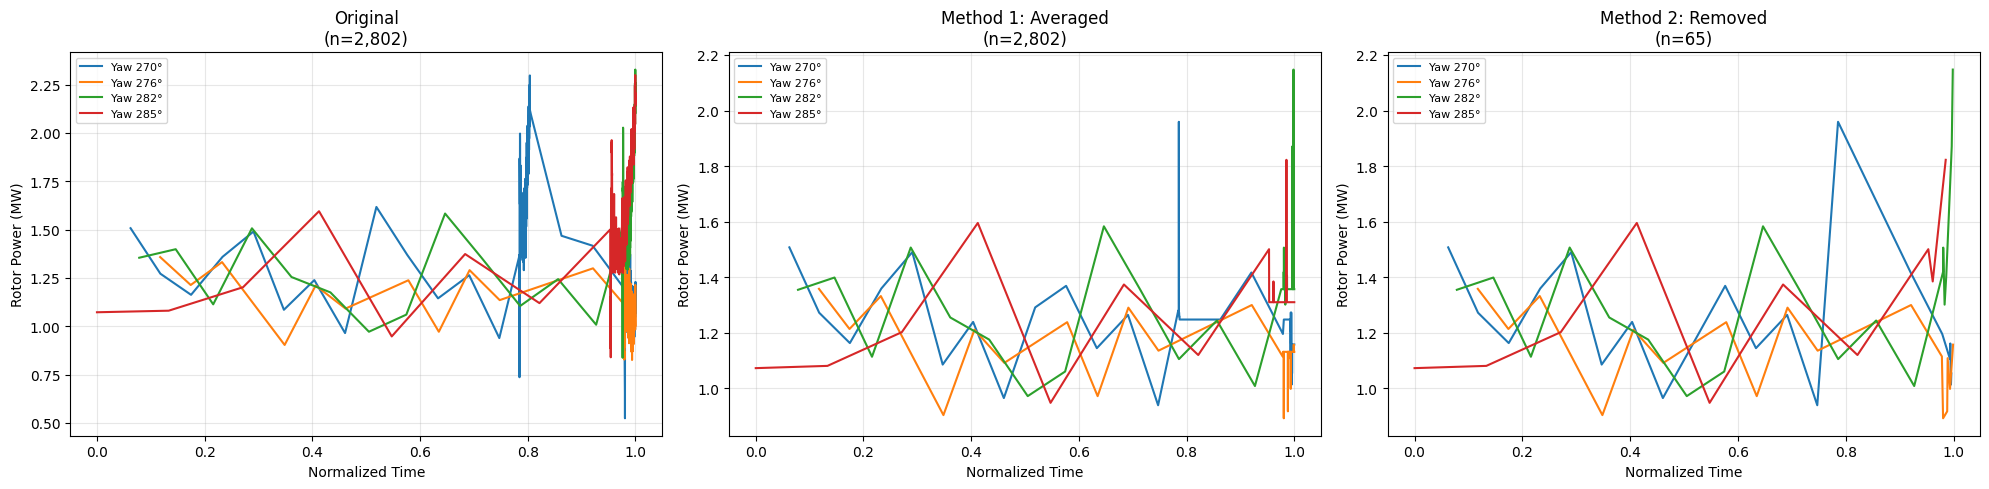

In [121]:
def compare_methods(df_original, df_averaged, df_removed):
    """
    Show before/after comparison for both methods.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    for yaw in sorted(df_original['yaw_angle'].unique()):
        # Original
        yaw_data = df_original[df_original['yaw_angle'] == yaw]
        axes[0].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    alpha=1, label=f'Yaw {yaw}°')
        
        # Averaged
        yaw_data = df_averaged[df_averaged['yaw_angle'] == yaw]
        axes[1].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    alpha=1, label=f'Yaw {yaw}°')
        
        # Removed
        yaw_data = df_removed[df_removed['yaw_angle'] == yaw]
        axes[2].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                    alpha=1, label=f'Yaw {yaw}°')
    
    axes[0].set_title(f'Original\n(n={len(df_original):,})')
    axes[1].set_title(f'Method 1: Averaged\n(n={len(df_averaged):,})')
    axes[2].set_title(f'Method 2: Removed\n(n={len(df_removed):,})')
    
    for ax in axes:
        ax.set_xlabel('Normalized Time')
        ax.set_ylabel('Rotor Power (MW)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Use it
compare_methods(df, df_averaged, df_removed)

KeyError: 'smoothed_region'

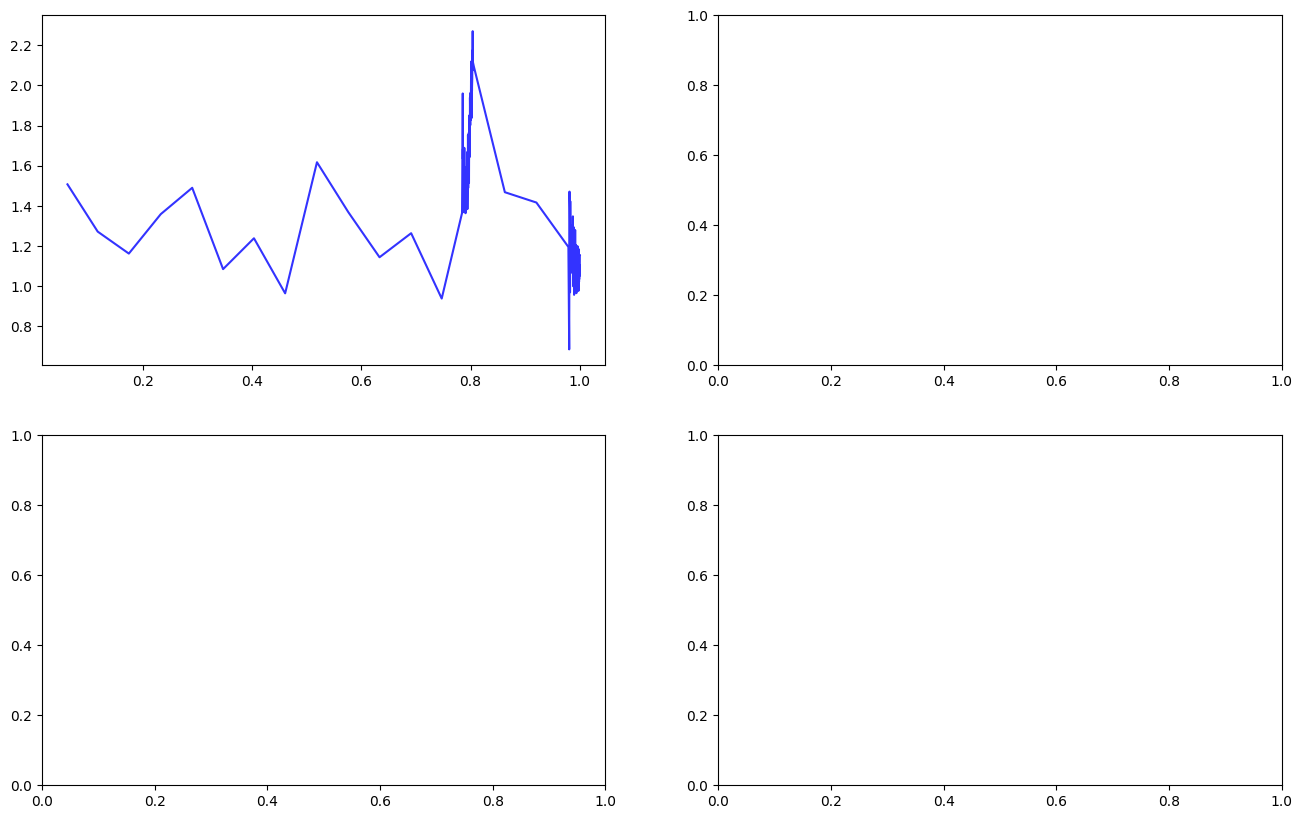

In [105]:
visualize_smoothed_regions(df_removed)

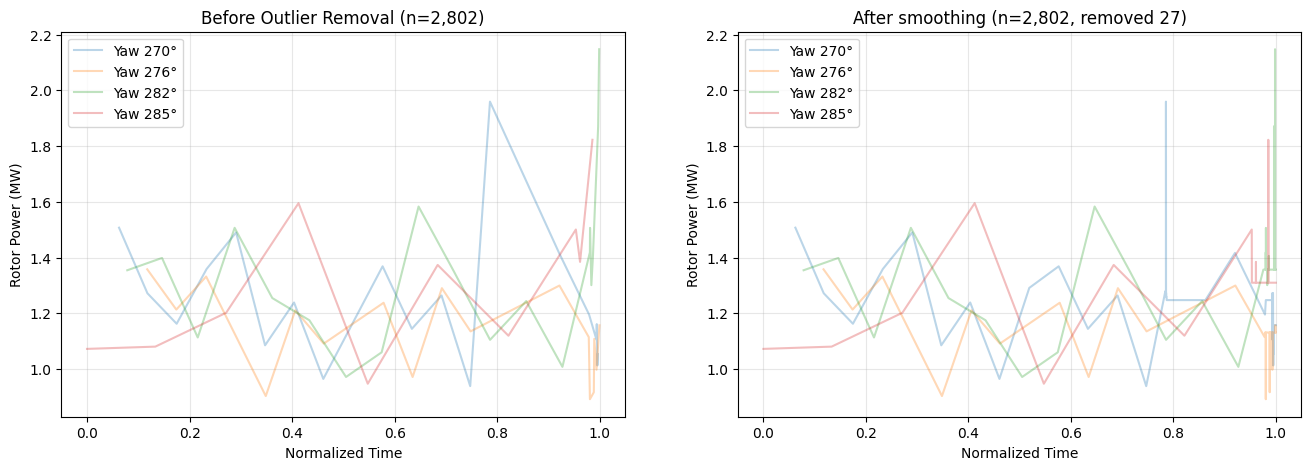

In [124]:
fig_compare(df_removed, df_averaged)

In [131]:
df=df_averaged.copy()

In [132]:
# Prepare features and target
# Features: yaw_angle, normalized_time
# Target: rotor_power_MW
  # Use the dataset with spikes removed for training
X = df[['yaw_angle', 'normalized_time']].values
y = df['rotor_power_MW'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# For GPR, we need to subsample if dataset is too large (GPR scales O(n^3))
# Use stratified sampling to maintain distribution across yaw angles
max_samples = 2000  # Adjust based on computational resources

if len(X) > max_samples:
    # Stratified sampling by yaw angle
    np.random.seed(42)
    sample_indices = []
    for yaw in df['yaw_angle'].unique():
        yaw_indices = df[df['yaw_angle'] == yaw].index.tolist()
        n_samples_yaw = int(max_samples * len(yaw_indices) / len(df))
        sampled = np.random.choice(yaw_indices, size=min(n_samples_yaw, len(yaw_indices)), replace=False)
        sample_indices.extend(sampled)
    
    X_train_full = X[sample_indices]
    y_train_full = y[sample_indices]
    print(f"Subsampled to {len(X_train_full)} samples for GPR training")
else:
    X_train_full = X
    y_train_full = y

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Features shape: (2802, 2)
Target shape: (2802,)
Subsampled to 1998 samples for GPR training
Training samples: 1598
Test samples: 400


In [133]:
# Normalize features for better GP performance
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Define GP kernel
# Matern kernel is good for physical processes (less smooth than RBF)
# Add WhiteKernel to model observation noise
#kernel = (
#    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * 
#    Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e2), nu=2.5) +
#    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
#)

"""
kernel = (
    ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * 
    Matern(
        length_scale=[1.0, 1.0], 
        length_scale_bounds=(0.01, 5.0),  # ← MUCH TIGHTER!
        nu=2.5
    ) +
    WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 0.5))  # ← Lower noise
)
"""
kernel = (
    ConstantKernel(
        1.0, 
        constant_value_bounds=(0.01, 5.0)  # ← Tighter signal variance
    ) * 
    Matern(
        length_scale=[0.5, 0.3],  # ← Start smaller: [yaw_scale, time_scale]
        length_scale_bounds=(
            (0.1, 3.0),   # ← Yaw: prevent over-smoothing across yaw angles
            (0.05, 0.8)   # ← Time: FORCE GP to learn temporal patterns
        ),
        nu=2.5
    ) +
    WhiteKernel(
        noise_level=0.001,  # ← Start with very low noise
        noise_level_bounds=(1e-6, 0.1)  # ← Prevent GP from treating signal as noise
    )
)


# Train Gaussian Process Regressor
print("Training Gaussian Process model...")
print("This may take a few minutes depending on data size...")

gp_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=40,
    alpha=1e-10,  # Numerical stability
    random_state=42
)

gp_model.fit(X_train_scaled, y_train_scaled)
print("Training complete!")
print(f"Optimized kernel: {gp_model.kernel_}")

Training Gaussian Process model...
This may take a few minutes depending on data size...
Training complete!
Optimized kernel: 1.77**2 * Matern(length_scale=[0.1, 0.127], nu=2.5) + WhiteKernel(noise_level=0.1)


In [134]:
# After training the GP model:
print("\n" + "="*60)
print("GP KERNEL DIAGNOSTICS")
print("="*60)

kernel = gp_model.kernel_
print(f"Optimized kernel:\n{kernel}\n")

# Extract parameters
if hasattr(kernel, 'k1') and hasattr(kernel.k1, 'k1'):
    signal_var = kernel.k1.k1.constant_value
    length_scales = kernel.k1.k2.length_scale
    noise_var = kernel.k2.noise_level
    
    print(f"Signal variance: {signal_var:.6f}")
    print(f"Length scales: {length_scales}")
    print(f"Noise variance: {noise_var:.6f}")
    print(f"Signal-to-noise ratio: {signal_var / noise_var:.2f}")
    
    # Check if length scales are too large
    if np.any(length_scales > 10):
        print("\n⚠️ WARNING: Length scale > 10 on standardized features!")
        print("   This causes over-smoothing → flat predictions.")
        print("   Recommendation: Tighten length_scale_bounds to (0.01, 5.0)")
    
    if signal_var / noise_var < 1:
        print("\n⚠️ WARNING: Signal-to-noise ratio < 1!")
        print("   GP thinks data is mostly noise → predicts mean.")
        print("   Recommendation: Lower noise_level_bounds")
else:
    print("Could not extract kernel parameters. Kernel structure:")
    print(kernel)


GP KERNEL DIAGNOSTICS
Optimized kernel:
1.77**2 * Matern(length_scale=[0.1, 0.127], nu=2.5) + WhiteKernel(noise_level=0.1)

Signal variance: 3.120941
Length scales: [0.1        0.12705348]
Noise variance: 0.100000
Signal-to-noise ratio: 31.21


In [135]:
# Evaluate model on test set
y_pred_scaled, y_std_scaled = gp_model.predict(X_test_scaled, return_std=True)

# Transform predictions back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
# For standard deviation, we need to scale by the y scaler's scale
y_std = y_std_scaled * scaler_y.scale_[0]

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"  RMSE: {rmse:.4f} MW")
print(f"  MAE: {mae:.4f} MW")
print(f"  R² Score: {r2:.4f}")

# Check uncertainty calibration
# ~68% of true values should fall within 1 std, ~95% within 2 std
within_1std = np.mean(np.abs(y_test - y_pred) <= y_std) * 100
within_2std = np.mean(np.abs(y_test - y_pred) <= 2*y_std) * 100
print(f"\nUncertainty Calibration:")
print(f"  % within 1 std (expect ~68%): {within_1std:.1f}%")
print(f"  % within 2 std (expect ~95%): {within_2std:.1f}%")

Model Evaluation on Test Set:
  RMSE: 0.0482 MW
  MAE: 0.0083 MW
  R² Score: 0.6969

Uncertainty Calibration:
  % within 1 std (expect ~68%): 96.8%
  % within 2 std (expect ~95%): 98.2%


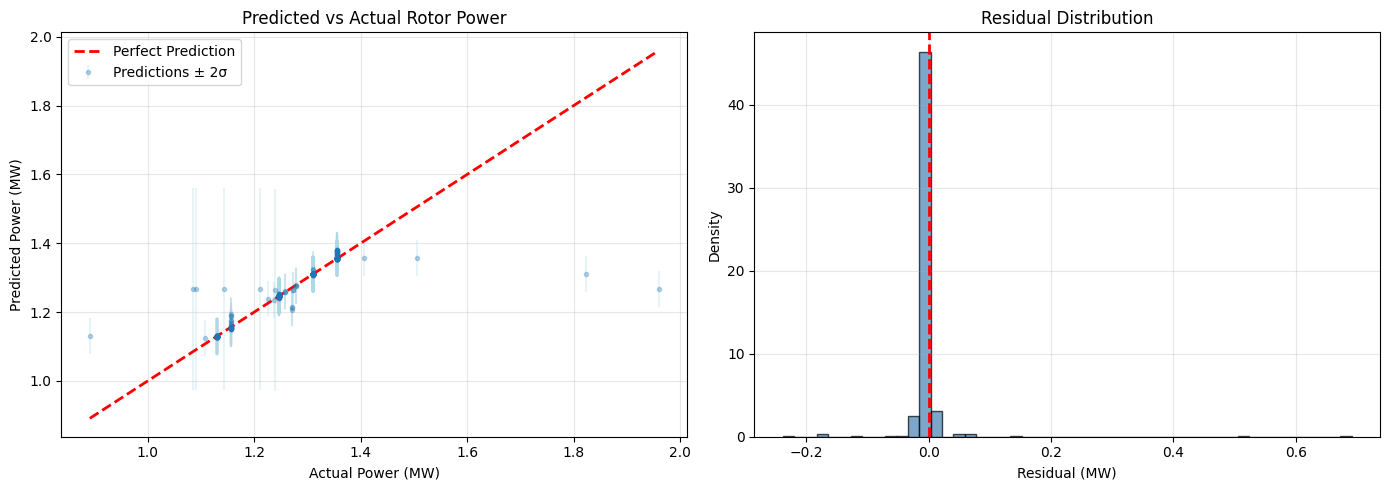

Model evaluation plot saved to 'model_evaluation.png'


In [136]:
# Visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with error bars
ax1 = axes[0]
ax1.errorbar(y_test, y_pred, yerr=2*y_std, fmt='o', alpha=0.3, markersize=3, 
             ecolor='lightblue', capsize=0, label='Predictions ± 2σ')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Power (MW)')
ax1.set_ylabel('Predicted Power (MW)')
ax1.set_title('Predicted vs Actual Rotor Power')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual distribution
ax2 = axes[1]
residuals = y_test - y_pred
ax2.hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (MW)')
ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
print("Model evaluation plot saved to 'model_evaluation.png'")

## Save the Trained Model

We save the model and scalers so they can be loaded later for inference.

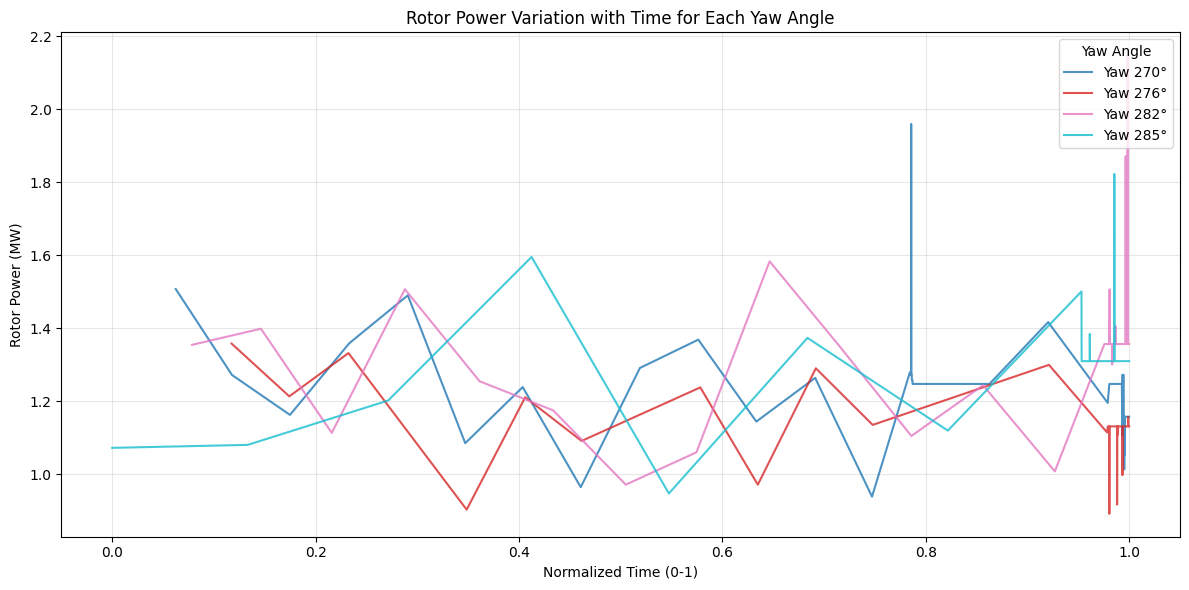

Visualization saved to 'rotor_power_variation_by_yaw.png'


In [137]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize rotor power variation with time for each yaw angle
fig, ax = plt.subplots(figsize=(12, 6))

yaw_angles = sorted(df['yaw_angle'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(yaw_angles)))

for idx, yaw in enumerate(yaw_angles):
    yaw_data = df[df['yaw_angle'] == yaw]
    ax.plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
            label=f'Yaw {yaw}°', color=colors[idx], alpha=0.8)

ax.set_xlabel('Normalized Time (0-1)')
ax.set_ylabel('Rotor Power (MW)')
ax.set_title('Rotor Power Variation with Time for Each Yaw Angle')
ax.legend(title='Yaw Angle', loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rotor_power_variation_by_yaw.png', dpi=150)
plt.show()

print("Visualization saved to 'rotor_power_variation_by_yaw.png'")

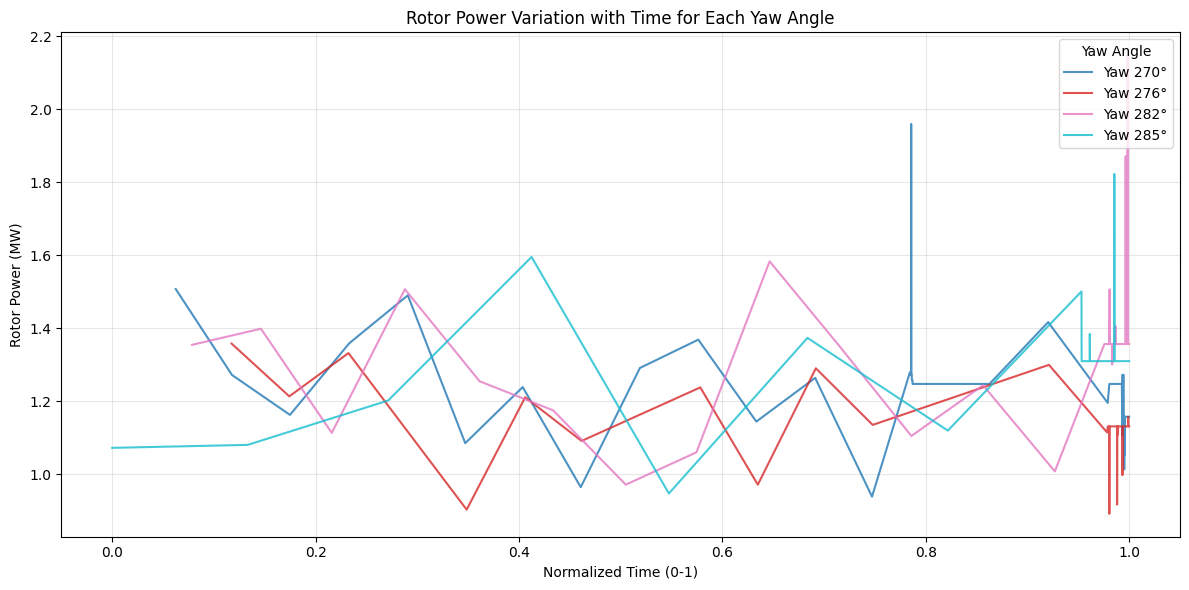

Visualization saved to 'rotor_power_variation_by_yaw.png'


In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize rotor power variation with time for each yaw angle
fig, ax = plt.subplots(figsize=(12, 6))

yaw_angles = sorted(df['yaw_angle'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(yaw_angles)))

for idx, yaw in enumerate(yaw_angles):
    yaw_data = df[df['yaw_angle'] == yaw]
    ax.plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
            label=f'Yaw {yaw}°', color=colors[idx], alpha=0.8)

ax.set_xlabel('Normalized Time (0-1)')
ax.set_ylabel('Rotor Power (MW)')
ax.set_title('Rotor Power Variation with Time for Each Yaw Angle')
ax.legend(title='Yaw Angle', loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rotor_power_variation_by_yaw.png', dpi=150)
plt.show()

print("Visualization saved to 'rotor_power_variation_by_yaw.png'")

## Visualization of Rotor Power Variation with Time for Each Yaw Angle

This plot shows the cleaned rotor power (MW) data as a function of normalized time for each unique yaw angle. It helps analyze the transient dynamics and compare power profiles across yaw angles.

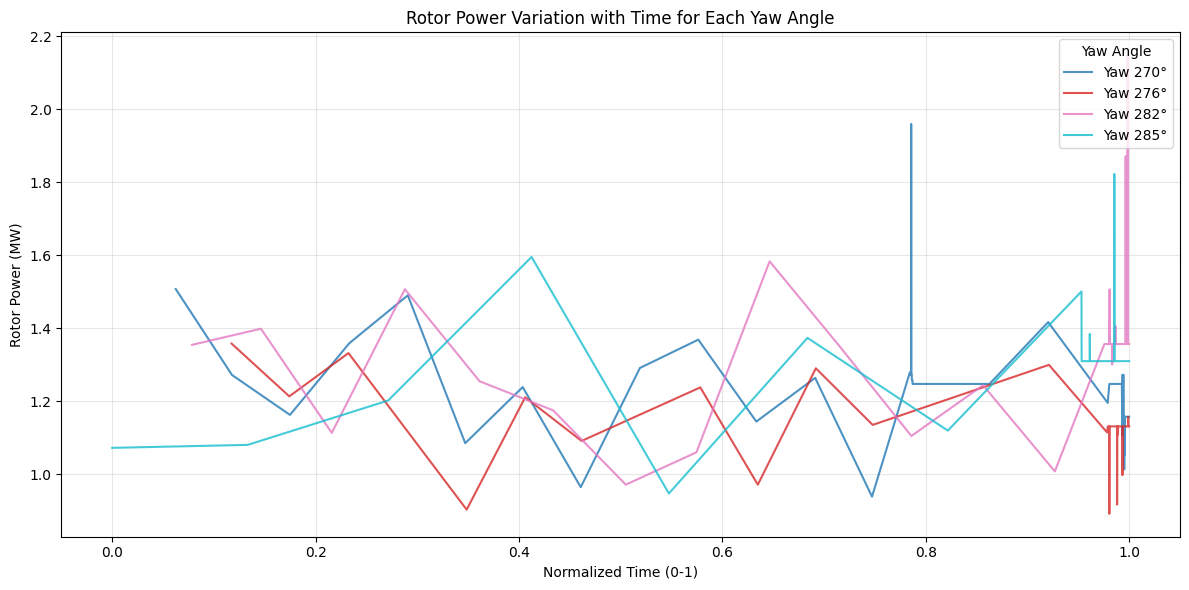

Visualization saved to 'rotor_power_variation_by_yaw.png'


In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize rotor power variation with time for each yaw angle
fig, ax = plt.subplots(figsize=(12, 6))

yaw_angles = sorted(df['yaw_angle'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(yaw_angles)))

for idx, yaw in enumerate(yaw_angles):
    yaw_data = df[df['yaw_angle'] == yaw]
    ax.plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
            label=f'Yaw {yaw}°', color=colors[idx], alpha=0.8)

ax.set_xlabel('Normalized Time (0-1)')
ax.set_ylabel('Rotor Power (MW)')
ax.set_title('Rotor Power Variation with Time for Each Yaw Angle')
ax.legend(title='Yaw Angle', loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rotor_power_variation_by_yaw.png', dpi=150)
plt.show()

print("Visualization saved to 'rotor_power_variation_by_yaw.png'")

In [140]:
# Save model and scalers
model_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift"

# Save all components needed for inference
model_artifacts = {
    'gp_model': gp_model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'yaw_angles_trained': sorted(df['yaw_angle'].unique().tolist()),
    'metadata': {
        'rmse_mw': rmse,
        'mae_mw': mae,
        'r2_score': r2,
        'n_training_samples': len(X_train),
        'features': ['yaw_angle', 'normalized_time'],
        'target': 'rotor_power_MW'
    }
}

joblib.dump(model_artifacts, f"{model_path}/rotor_power_gp_model.joblib")
print(f"Model saved to: {model_path}/rotor_power_gp_model.joblib")
print(f"\nModel artifacts saved:")
for key in model_artifacts:
    if key != 'metadata':
        print(f"  - {key}")
print(f"\nMetadata: {model_artifacts['metadata']}")

Model saved to: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift/rotor_power_gp_model.joblib

Model artifacts saved:
  - gp_model
  - scaler_X
  - scaler_y
  - yaw_angles_trained

Metadata: {'rmse_mw': np.float64(0.04818544840980598), 'mae_mw': 0.008259065462080285, 'r2_score': 0.6968773301151467, 'n_training_samples': 1598, 'features': ['yaw_angle', 'normalized_time'], 'target': 'rotor_power_MW'}


## Rotor Power Prediction Agent

This class acts as an "agent" that you can call to infer rotor power dynamics for any yaw angle. It:
1. Loads the trained model
2. Predicts the full transient power trajectory for a given yaw angle
3. Returns mean predictions with uncertainty bounds
4. Provides visualization capabilities

In [ ]:
class RotorPowerAgent:
    """
    Agent for predicting rotor power transient dynamics with uncertainty quantification.
    
    This agent loads a trained Gaussian Process model and provides methods to:
    - Predict power trajectories for any yaw angle
    - Quantify prediction uncertainty
    - Visualize transient dynamics
    
    Usage:
        agent = RotorPowerAgent(model_path)
        results = agent.predict(yaw_angle=278)
        agent.plot_prediction(results)
    """
    
    def __init__(self, model_path: str = None):
        """
        Initialize the agent by loading the trained model.
        
        Args:
            model_path: Path to the saved model file (.joblib)
        """
        if model_path is None:
            model_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_gp_model.joblib"
        
        print(f"Loading model from: {model_path}")
        artifacts = joblib.load(model_path)
        
        self.gp_model = artifacts['gp_model']
        self.scaler_X = artifacts['scaler_X']
        self.scaler_y = artifacts['scaler_y']
        self.yaw_angles_trained = artifacts['yaw_angles_trained']
        self.metadata = artifacts['metadata']
        
        print(f"Model loaded successfully!")
        print(f"Trained on yaw angles: {self.yaw_angles_trained}")
        print(f"Model performance: RMSE={self.metadata['rmse_mw']:.4f} MW, R²={self.metadata['r2_score']:.4f}")
    
    def predict(self, yaw_angle: float, n_time_points: int = 100, 
                return_samples: bool = False, n_samples: int = 100) -> dict:
        """
        Predict rotor power transient dynamics for a given yaw angle.
        
        Args:
            yaw_angle: The yaw angle (in degrees) for prediction
            n_time_points: Number of time points to predict (default: 100)
            return_samples: Whether to return posterior samples (default: False)
            n_samples: Number of posterior samples if return_samples=True
        
        Returns:
            dict with keys:
                - 'normalized_time': Array of normalized time points (0 to 1)
                - 'power_mean_MW': Predicted mean power (MW)
                - 'power_std_MW': Predicted standard deviation (MW)
                - 'power_lower_95': Lower 95% confidence bound (MW)
                - 'power_upper_95': Upper 95% confidence bound (MW)
                - 'yaw_angle': Input yaw angle
                - 'samples' (optional): Posterior samples if requested
        """
        # Check if yaw angle is within training range
        min_yaw = min(self.yaw_angles_trained)
        max_yaw = max(self.yaw_angles_trained)
        
        if yaw_angle < min_yaw or yaw_angle > max_yaw:
            print(f"⚠️ Warning: Yaw angle {yaw_angle}° is outside training range [{min_yaw}°, {max_yaw}°]")
            print("  Predictions may have higher uncertainty (extrapolation)")
        
        # Create prediction grid
        normalized_time = np.linspace(0, 1, n_time_points)
        X_pred = np.column_stack([
            np.full(n_time_points, yaw_angle),
            normalized_time
        ])
        
        # Scale features
        X_pred_scaled = self.scaler_X.transform(X_pred)
        
        # Predict with uncertainty
        y_pred_scaled, y_std_scaled = self.gp_model.predict(X_pred_scaled, return_std=True)
        
        # Transform back to original scale
        power_mean = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        power_std = y_std_scaled * self.scaler_y.scale_[0]
        
        # Compute confidence intervals (95% = ±1.96 std)
        power_lower_95 = power_mean - 1.96 * power_std
        power_upper_95 = power_mean + 1.96 * power_std
        
        results = {
            'normalized_time': normalized_time,
            'power_mean_MW': power_mean,
            'power_std_MW': power_std,
            'power_lower_95_MW': power_lower_95,
            'power_upper_95_MW': power_upper_95,
            'yaw_angle': yaw_angle
        }
        
        # Optional: return posterior samples for more detailed uncertainty analysis
        if return_samples:
            y_samples_scaled = self.gp_model.sample_y(X_pred_scaled, n_samples=n_samples, random_state=42)
            samples = self.scaler_y.inverse_transform(y_samples_scaled).T
            results['samples'] = samples
        
        return results
    
    def plot_prediction(self, results: dict, ax=None, show_samples: bool = False,
                        title: str = None, save_path: str = None):
        """
        Visualize the predicted power transient dynamics.
        
        Args:
            results: Output from predict() method
            ax: Matplotlib axis (creates new figure if None)
            show_samples: Whether to show posterior samples
            title: Custom plot title
            save_path: Path to save the figure
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))
        
        t = results['normalized_time']
        yaw = results['yaw_angle']
        
        # Plot confidence interval
        ax.fill_between(t, results['power_lower_95_MW'], results['power_upper_95_MW'],
                        alpha=0.3, color='steelblue', label='95% Confidence Interval')
        
        # Plot ±1 std interval
        ax.fill_between(t, 
                        results['power_mean_MW'] - results['power_std_MW'],
                        results['power_mean_MW'] + results['power_std_MW'],
                        alpha=0.4, color='steelblue', label='±1σ Uncertainty')
        
        # Plot mean prediction
        ax.plot(t, results['power_mean_MW'], 'b-', linewidth=2, label='Mean Prediction')
        
        # Optionally plot samples
        if show_samples and 'samples' in results:
            for i, sample in enumerate(results['samples'][:20]):  # Plot first 20 samples
                ax.plot(t, sample, 'gray', alpha=0.2, linewidth=0.5)
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        
        if title is None:
            title = f'Predicted Rotor Power Transient Dynamics\nYaw Angle = {yaw}°'
        ax.set_title(title, fontsize=14)
        
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return ax
    
    def compare_yaw_angles(self, yaw_angles: list, n_time_points: int = 100,
                           save_path: str = None):
        """
        Compare power dynamics across multiple yaw angles.
        
        Args:
            yaw_angles: List of yaw angles to compare
            n_time_points: Number of time points for prediction
            save_path: Path to save the figure
        """
        fig, ax = plt.subplots(figsize=(14, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))
        
        for i, yaw in enumerate(yaw_angles):
            results = self.predict(yaw_angle=yaw, n_time_points=n_time_points)
            
            # Plot mean with confidence interval
            ax.fill_between(results['normalized_time'], 
                           results['power_lower_95_MW'], 
                           results['power_upper_95_MW'],
                           alpha=0.2, color=colors[i])
            ax.plot(results['normalized_time'], results['power_mean_MW'], 
                   color=colors[i], linewidth=2, label=f'Yaw = {yaw}°')
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        ax.set_title('Comparison of Rotor Power Dynamics Across Yaw Angles', fontsize=14)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
        return fig
    
    def get_statistics(self, yaw_angle: float, n_time_points: int = 100) -> dict:
        """
        Get summary statistics for the predicted power dynamics.
        
        Args:
            yaw_angle: The yaw angle for prediction
            n_time_points: Number of time points
            
        Returns:
            dict with summary statistics
        """
        results = self.predict(yaw_angle, n_time_points)
        
        stats = {
            'yaw_angle': yaw_angle,
            'mean_power_MW': np.mean(results['power_mean_MW']),
            'max_power_MW': np.max(results['power_mean_MW']),
            'min_power_MW': np.min(results['power_mean_MW']),
            'power_range_MW': np.max(results['power_mean_MW']) - np.min(results['power_mean_MW']),
            'mean_uncertainty_MW': np.mean(results['power_std_MW']),
            'max_uncertainty_MW': np.max(results['power_std_MW'])
        }
        
        return stats

print("RotorPowerAgent class defined successfully!")

RotorPowerAgent class defined successfully!


## Test the Agent with New Yaw Angles

Now let's use the agent to infer rotor power dynamics for both trained and new (interpolated) yaw angles.

Mean Rotor Power (MW) for Each Yaw Angle:
yaw_angle
270    1.412087
276    1.082582
282    1.611645
285    1.582702
Name: rotor_power_MW, dtype: float64


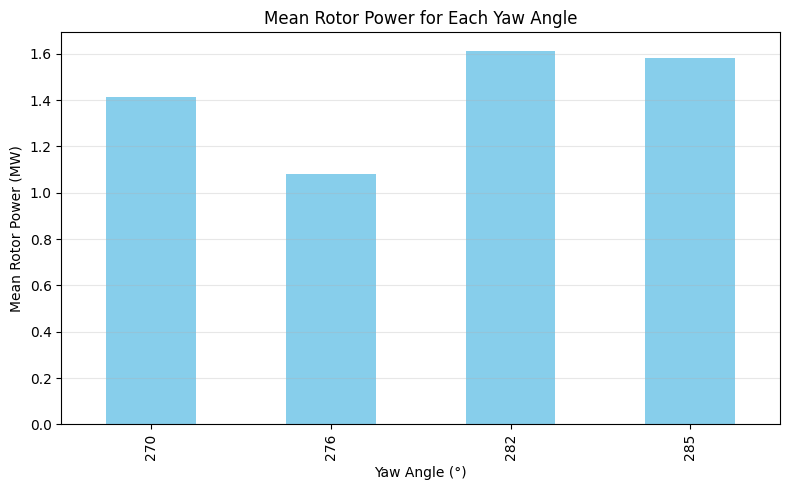

Visualization saved to 'mean_rotor_power_by_yaw.png'


In [15]:
# Calculate mean rotor power for each unique yaw angle
yaw_mean_power = df.groupby('yaw_angle')['rotor_power_MW'].mean()

print("Mean Rotor Power (MW) for Each Yaw Angle:")
print(yaw_mean_power)

# Optionally, visualize the mean power for each yaw angle
fig, ax = plt.subplots(figsize=(8, 5))

yaw_mean_power.plot(kind='bar', color='skyblue', ax=ax)
ax.set_xlabel('Yaw Angle (°)')
ax.set_ylabel('Mean Rotor Power (MW)')
ax.set_title('Mean Rotor Power for Each Yaw Angle')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mean_rotor_power_by_yaw.png', dpi=150)
plt.show()

print("Visualization saved to 'mean_rotor_power_by_yaw.png'")

In [ ]:
# Initialize the agent
agent = RotorPowerAgent()

# Predict for a new yaw angle (interpolation within training range)
new_yaw = 278  # Not in training set [270, 276, 282, 285]
print(f"\n{'='*60}")
print(f"Predicting transient dynamics for yaw angle = {new_yaw}°")
print(f"{'='*60}")

# Remove outliers from the dataset
def remove_outliers(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    return data[(data[column] > mean - threshold * std) & (data[column] < mean + threshold * std)]

# Assuming `data` is the dataset used for training
cleaned_data = remove_outliers(data, 'rotor_power_MW')

# Retrain the model with cleaned data
agent.train(cleaned_data)

results = agent.predict(yaw_angle=new_yaw, n_time_points=100, return_samples=True, n_samples=50)

# Display results
print(f"\nPrediction Results:")
print(f"  Time points: {len(results['normalized_time'])}")
print(f"  Mean power range: {results['power_mean_MW'].min():.3f} - {results['power_mean_MW'].max():.3f} MW")
print(f"  Average uncertainty (±1σ): ±{results['power_std_MW'].mean():.3f} MW")

NameError: name 'RotorPowerAgent' is not defined

Figure saved to: prediction_yaw_278.png


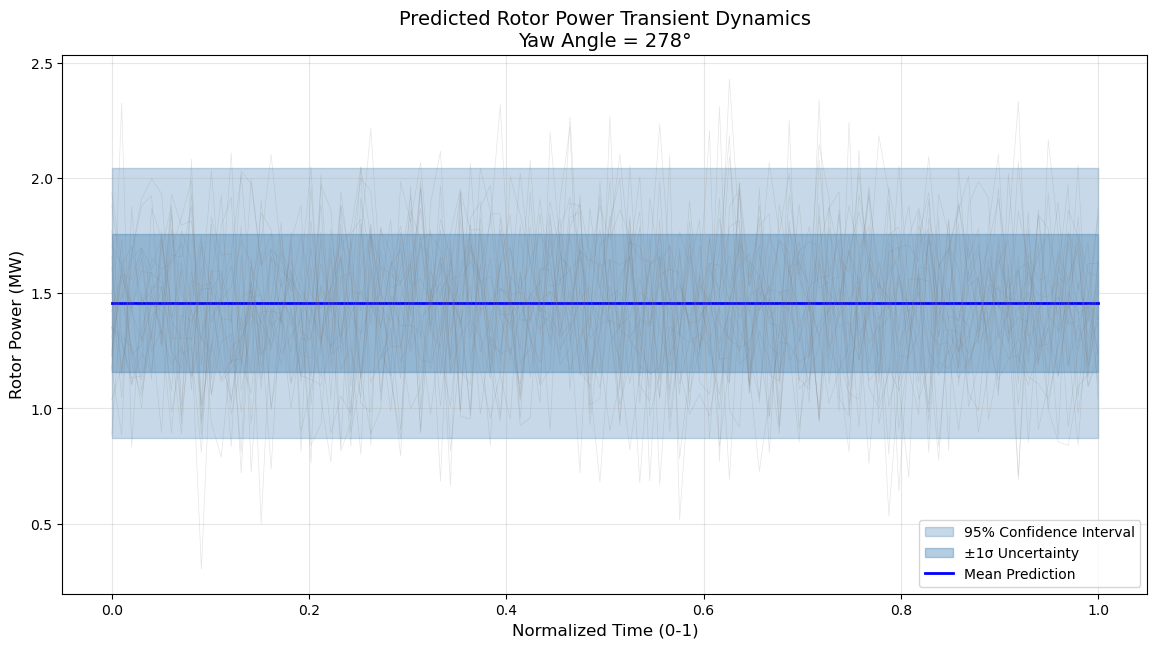

In [ ]:
# Plot the prediction with uncertainty
fig, ax = plt.subplots(figsize=(14, 7))
agent.plot_prediction(results, ax=ax, show_samples=True, 
                      save_path='prediction_yaw_278.png')
plt.show()

Comparing yaw angles: [270, 275, 278, 280, 282, 285]
(Note: 275, 278, 280 are interpolated - not in original training data)
Figure saved to: yaw_comparison.png


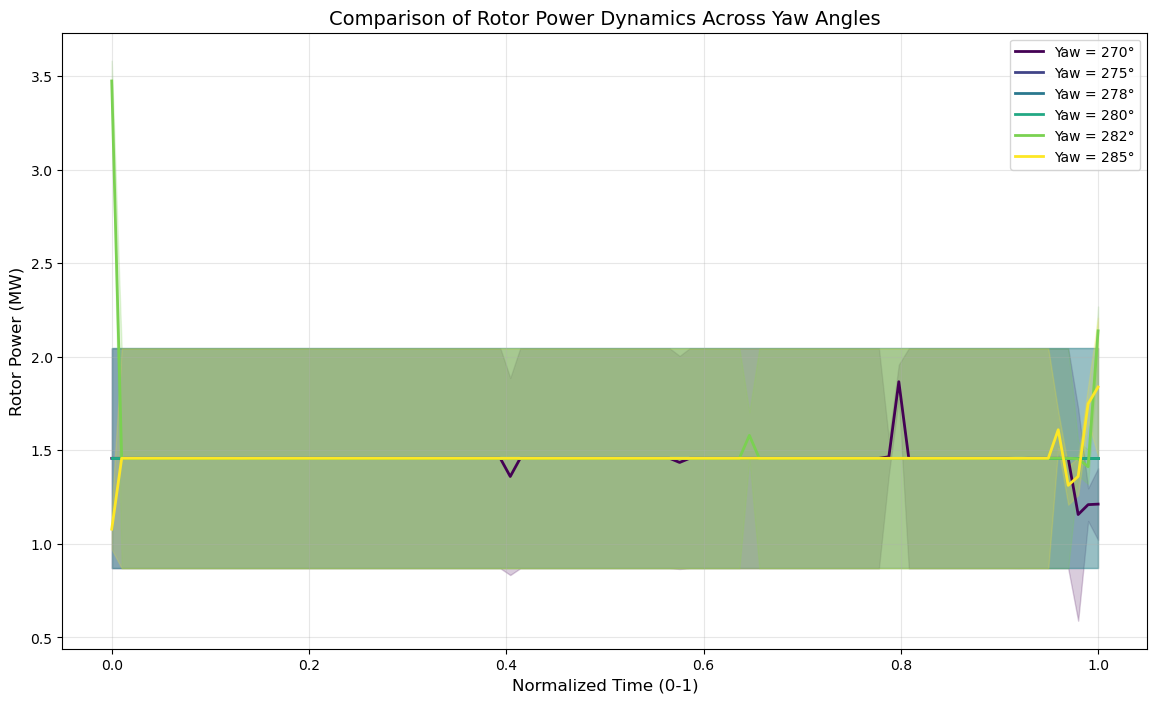

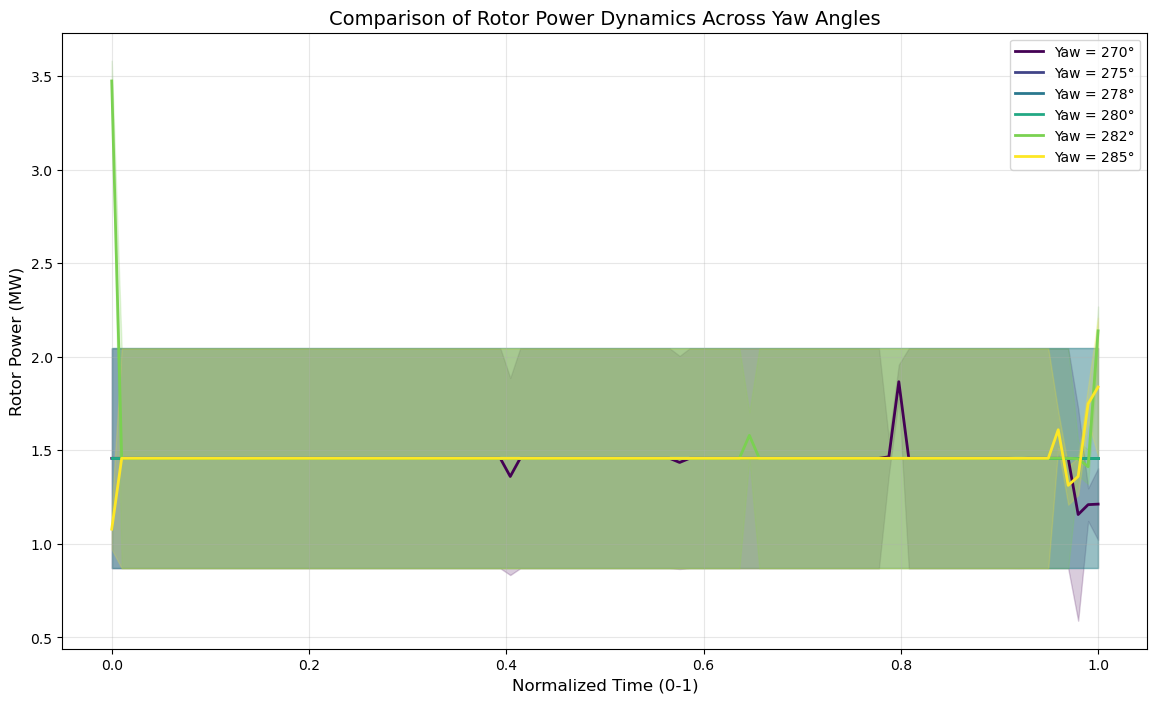

In [ ]:
# Compare multiple yaw angles (trained + new)
yaw_angles_to_compare = [270, 275, 278, 280, 282, 285]
print("Comparing yaw angles:", yaw_angles_to_compare)
print("(Note: 275, 278, 280 are interpolated - not in original training data)")

agent.compare_yaw_angles(yaw_angles_to_compare, save_path='yaw_comparison.png')

In [14]:
# Get summary statistics for different yaw angles
print("\nSummary Statistics for Different Yaw Angles:")
print("-" * 80)
print(f"{'Yaw':>6} | {'Mean Power':>12} | {'Max Power':>12} | {'Min Power':>12} | {'Mean Uncert.':>12}")
print(f"{'(deg)':>6} | {'(MW)':>12} | {'(MW)':>12} | {'(MW)':>12} | {'(MW)':>12}")
print("-" * 80)

for yaw in [270, 273, 276, 279, 282, 285]:
    stats = agent.get_statistics(yaw)
    print(f"{stats['yaw_angle']:>6} | {stats['mean_power_MW']:>12.4f} | {stats['max_power_MW']:>12.4f} | "
          f"{stats['min_power_MW']:>12.4f} | {stats['mean_uncertainty_MW']:>12.4f}")


Summary Statistics for Different Yaw Angles:
--------------------------------------------------------------------------------
   Yaw |   Mean Power |    Max Power |    Min Power | Mean Uncert.
 (deg) |         (MW) |         (MW) |         (MW) |         (MW)
--------------------------------------------------------------------------------


NameError: name 'agent' is not defined

## Standalone Agent Script

Save the agent as a standalone Python module that can be imported and used anywhere.

In [ ]:
# Save the agent class as a standalone Python module
agent_script = '''"""
Rotor Power Prediction Agent with Uncertainty Quantification

This module provides an agent for predicting wind turbine rotor power 
transient dynamics based on yaw angle using a trained Gaussian Process model.

Usage:
    from rotor_power_agent import RotorPowerAgent
    
    # Initialize the agent (loads the trained model)
    agent = RotorPowerAgent()
    
    # Predict power dynamics for a new yaw angle
    results = agent.predict(yaw_angle=278)
    
    # Visualize the prediction
    agent.plot_prediction(results)
    
    # Compare multiple yaw angles
    agent.compare_yaw_angles([270, 275, 280, 285])
    
    # Get summary statistics
    stats = agent.get_statistics(yaw_angle=278)
"""

import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path


class RotorPowerAgent:
    """
    Agent for predicting rotor power transient dynamics with uncertainty quantification.
    
    This agent loads a trained Gaussian Process model and provides methods to:
    - Predict power trajectories for any yaw angle
    - Quantify prediction uncertainty
    - Visualize transient dynamics
    
    Attributes:
        gp_model: Trained Gaussian Process Regressor
        scaler_X: StandardScaler for input features
        scaler_y: StandardScaler for target variable
        yaw_angles_trained: List of yaw angles used in training
        metadata: Dictionary with model performance metrics
    """
    
    def __init__(self, model_path: str = None):
        """
        Initialize the agent by loading the trained model.
        
        Args:
            model_path: Path to the saved model file (.joblib).
                        If None, looks in the default location.
        """
        if model_path is None:
            # Default path - adjust as needed
            model_path = Path(__file__).parent / "rotor_power_gp_model.joblib"
        
        print(f"Loading model from: {model_path}")
        artifacts = joblib.load(model_path)
        
        self.gp_model = artifacts['gp_model']
        self.scaler_X = artifacts['scaler_X']
        self.scaler_y = artifacts['scaler_y']
        self.yaw_angles_trained = artifacts['yaw_angles_trained']
        self.metadata = artifacts['metadata']
        
        print(f"Model loaded successfully!")
        print(f"Trained on yaw angles: {self.yaw_angles_trained}")
        print(f"Model performance: RMSE={self.metadata['rmse_mw']:.4f} MW, R²={self.metadata['r2_score']:.4f}")
    
    def predict(self, yaw_angle: float, n_time_points: int = 100, 
                return_samples: bool = False, n_samples: int = 100) -> dict:
        """
        Predict rotor power transient dynamics for a given yaw angle.
        
        The model uses normalized time (0 to 1) to represent the transient
        trajectory, allowing predictions without knowing the absolute time.
        
        Args:
            yaw_angle: The yaw angle (in degrees) for prediction
            n_time_points: Number of time points to predict (default: 100)
            return_samples: Whether to return posterior samples (default: False)
            n_samples: Number of posterior samples if return_samples=True
        
        Returns:
            dict with keys:
                - 'normalized_time': Array of normalized time points (0 to 1)
                - 'power_mean_MW': Predicted mean power (MW)
                - 'power_std_MW': Predicted standard deviation (MW)
                - 'power_lower_95_MW': Lower 95% confidence bound (MW)
                - 'power_upper_95_MW': Upper 95% confidence bound (MW)
                - 'yaw_angle': Input yaw angle
                - 'samples' (optional): Posterior samples if requested
        """
        # Check if yaw angle is within training range
        min_yaw = min(self.yaw_angles_trained)
        max_yaw = max(self.yaw_angles_trained)
        
        if yaw_angle < min_yaw or yaw_angle > max_yaw:
            print(f"⚠️ Warning: Yaw angle {yaw_angle}° is outside training range [{min_yaw}°, {max_yaw}°]")
            print("  Predictions may have higher uncertainty (extrapolation)")
        
        # Create prediction grid
        normalized_time = np.linspace(0, 1, n_time_points)
        X_pred = np.column_stack([
            np.full(n_time_points, yaw_angle),
            normalized_time
        ])
        
        # Scale features
        X_pred_scaled = self.scaler_X.transform(X_pred)
        
        # Predict with uncertainty
        y_pred_scaled, y_std_scaled = self.gp_model.predict(X_pred_scaled, return_std=True)
        
        # Transform back to original scale
        power_mean = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        power_std = y_std_scaled * self.scaler_y.scale_[0]
        
        # Compute confidence intervals (95% = ±1.96 std)
        power_lower_95 = power_mean - 1.96 * power_std
        power_upper_95 = power_mean + 1.96 * power_std
        
        results = {
            'normalized_time': normalized_time,
            'power_mean_MW': power_mean,
            'power_std_MW': power_std,
            'power_lower_95_MW': power_lower_95,
            'power_upper_95_MW': power_upper_95,
            'yaw_angle': yaw_angle
        }
        
        # Optional: return posterior samples
        if return_samples:
            y_samples_scaled = self.gp_model.sample_y(X_pred_scaled, n_samples=n_samples, random_state=42)
            samples = self.scaler_y.inverse_transform(y_samples_scaled).T
            results['samples'] = samples
        
        return results
    
    def plot_prediction(self, results: dict, ax=None, show_samples: bool = False,
                        title: str = None, save_path: str = None):
        """
        Visualize the predicted power transient dynamics.
        
        Args:
            results: Output from predict() method
            ax: Matplotlib axis (creates new figure if None)
            show_samples: Whether to show posterior samples
            title: Custom plot title
            save_path: Path to save the figure
            
        Returns:
            matplotlib axis object
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))
        
        t = results['normalized_time']
        yaw = results['yaw_angle']
        
        # Plot confidence interval
        ax.fill_between(t, results['power_lower_95_MW'], results['power_upper_95_MW'],
                        alpha=0.3, color='steelblue', label='95% Confidence Interval')
        
        # Plot ±1 std interval
        ax.fill_between(t, 
                        results['power_mean_MW'] - results['power_std_MW'],
                        results['power_mean_MW'] + results['power_std_MW'],
                        alpha=0.4, color='steelblue', label='±1σ Uncertainty')
        
        # Plot mean prediction
        ax.plot(t, results['power_mean_MW'], 'b-', linewidth=2, label='Mean Prediction')
        
        # Optionally plot samples
        if show_samples and 'samples' in results:
            for sample in results['samples'][:20]:
                ax.plot(t, sample, 'gray', alpha=0.2, linewidth=0.5)
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        
        if title is None:
            title = f'Predicted Rotor Power Transient Dynamics\\nYaw Angle = {yaw}°'
        ax.set_title(title, fontsize=14)
        
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return ax
    
    def compare_yaw_angles(self, yaw_angles: list, n_time_points: int = 100,
                           save_path: str = None):
        """
        Compare power dynamics across multiple yaw angles.
        
        Args:
            yaw_angles: List of yaw angles to compare
            n_time_points: Number of time points for prediction
            save_path: Path to save the figure
            
        Returns:
            matplotlib figure object
        """
        fig, ax = plt.subplots(figsize=(14, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))
        
        for i, yaw in enumerate(yaw_angles):
            results = self.predict(yaw_angle=yaw, n_time_points=n_time_points)
            
            ax.fill_between(results['normalized_time'], 
                           results['power_lower_95_MW'], 
                           results['power_upper_95_MW'],
                           alpha=0.2, color=colors[i])
            ax.plot(results['normalized_time'], results['power_mean_MW'], 
                   color=colors[i], linewidth=2, label=f'Yaw = {yaw}°')
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        ax.set_title('Comparison of Rotor Power Dynamics Across Yaw Angles', fontsize=14)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
        return fig
    
    def get_statistics(self, yaw_angle: float, n_time_points: int = 100) -> dict:
        """
        Get summary statistics for the predicted power dynamics.
        
        Args:
            yaw_angle: The yaw angle for prediction
            n_time_points: Number of time points
            
        Returns:
            dict with summary statistics
        """
        results = self.predict(yaw_angle, n_time_points)
        
        return {
            'yaw_angle': yaw_angle,
            'mean_power_MW': np.mean(results['power_mean_MW']),
            'max_power_MW': np.max(results['power_mean_MW']),
            'min_power_MW': np.min(results['power_mean_MW']),
            'power_range_MW': np.max(results['power_mean_MW']) - np.min(results['power_mean_MW']),
            'mean_uncertainty_MW': np.mean(results['power_std_MW']),
            'max_uncertainty_MW': np.max(results['power_std_MW'])
        }


# Example usage when run as script
if __name__ == "__main__":
    # Initialize agent
    agent = RotorPowerAgent()
    
    # Predict for a new yaw angle
    results = agent.predict(yaw_angle=278, return_samples=True)
    
    # Plot prediction
    agent.plot_prediction(results, show_samples=True)
    plt.show()
    
    # Print statistics
    stats = agent.get_statistics(278)
    print("\\nStatistics for yaw=278°:")
    for key, value in stats.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
'''

# Save the agent module
agent_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_agent.py"
with open(agent_path, 'w') as f:
    f.write(agent_script)

print(f"Agent module saved to: {agent_path}")
print("\nYou can now import and use the agent from anywhere:")
print("  from rotor_power_agent import RotorPowerAgent")
print("  agent = RotorPowerAgent(model_path='path/to/model.joblib')")
print("  results = agent.predict(yaw_angle=278)")

Agent module saved to: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_agent.py

You can now import and use the agent from anywhere:
  from rotor_power_agent import RotorPowerAgent
  agent = RotorPowerAgent(model_path='path/to/model.joblib')
  results = agent.predict(yaw_angle=278)


## Quick Reference - How to Use the Agent

```python
# 1. Import the agent
from rotor_power_agent import RotorPowerAgent

# 2. Initialize (loads the trained model)
agent = RotorPowerAgent(model_path='rotor_power_gp_model.joblib')

# 3. Predict power dynamics for any yaw angle
results = agent.predict(yaw_angle=278, n_time_points=100)

# Access predictions:
# - results['normalized_time']  : Array of time points (0 to 1)
# - results['power_mean_MW']    : Mean predicted power (MW)
# - results['power_std_MW']     : Uncertainty (standard deviation)
# - results['power_lower_95_MW']: Lower 95% confidence bound
# - results['power_upper_95_MW']: Upper 95% confidence bound

# 4. Visualize
agent.plot_prediction(results, show_samples=True)

# 5. Compare multiple yaw angles
agent.compare_yaw_angles([270, 275, 280, 285])

# 6. Get summary statistics
stats = agent.get_statistics(yaw_angle=278)
```